In [ ]:
#Imported the PCA European data using Pandas
import pandas as pd
df = pd.read_csv('/content/creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

#In order for the model to learn calssifcation, it needs to drop Class to not use it as an indicator to guess Class.
X = df.drop(columns=['Class']).values

# We are normalizing the data to be used for pytorch
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
#Once we can have it suitable for pytorch, we load the iterations by 70.

batch_size = 70
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)





In [ ]:
#This jsut checks if we have GPU to use, which we don't
#We then set up the dimensions and the noise to the data to ensure
#variability in the out put.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dim = X_tensor.shape[1]
noise_dim = 32
hidden_dim = 64

#Using our parameters, we use the pytorch genrator that
#sequentials applies linear, ReLU, Linear, ReLU, and Linear
#This is a common pattern for activation and layering
#The model moves forward
#The output is a row of data with the class now
class Generator(nn.Module):
    def __init__(self, noise_dim, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, z):
        return self.model(z)

#The discriminaotr uses a similar activation pattern
#but it is just guessing the class of the row.
class Discriminator(nn.Module):
    def __init__(self, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)   # no sigmoid here
        )

    def forward(self, x):
        return self.model(x)

G = Generator(noise_dim, data_dim).to(device)
D = Discriminator(data_dim).to(device)

In [ ]:
#Utilizing a cross entrophy loss
#The two models are agaisnt each other so we have to reward one at a time.
criterion = nn.BCEWithLogitsLoss()

#Using Adam optimization for learning parameters
g_optimizer = optim.Adam(G.parameters(), lr=0.0002)
d_optimizer = optim.Adam(D.parameters(), lr=0.0002)

#Training loop
epochs = 100

for epoch in range(epochs):
    for real_batch, in dataloader:
        real_batch = real_batch.to(device)
        batch_size_curr = real_batch.size(0)

        real_labels = torch.ones(batch_size_curr, 1, device=device)
        fake_labels = torch.zeros(batch_size_curr, 1, device=device)


        z = torch.randn(batch_size_curr, noise_dim, device=device)
        fake_batch = G(z)

        real_preds = D(real_batch)
        fake_preds = D(fake_batch.detach())

        d_real_loss = criterion(real_preds, real_labels)
        d_fake_loss = criterion(fake_preds, fake_labels)
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()


        z = torch.randn(batch_size_curr, noise_dim, device=device)
        fake_batch = G(z)
        fake_preds = D(fake_batch)

        g_loss = criterion(fake_preds, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
    #Printing results
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch [10/100] | D Loss: 0.6757 | G Loss: 1.5006
Epoch [20/100] | D Loss: 0.1182 | G Loss: 4.9746
Epoch [30/100] | D Loss: 0.5778 | G Loss: 3.5057
Epoch [40/100] | D Loss: 0.0768 | G Loss: 4.2279
Epoch [50/100] | D Loss: 0.0514 | G Loss: 4.6429
Epoch [60/100] | D Loss: 0.0518 | G Loss: 3.6505
Epoch [70/100] | D Loss: 0.2823 | G Loss: 4.9025
Epoch [80/100] | D Loss: 0.1100 | G Loss: 5.8841
Epoch [90/100] | D Loss: 0.1597 | G Loss: 4.1230
Epoch [100/100] | D Loss: 0.2960 | G Loss: 4.5298


In [ ]:
#Generation for data, needed some help with ai for code.
#We are basically reversing the process to look like the raw data
G.eval()
with torch.no_grad():
    n_samples = 10
    z = torch.randn(n_samples, noise_dim, device=device)
    synthetic_data = G(z).cpu().numpy()

synthetic_data_original = scaler.inverse_transform(synthetic_data)
synthetic_df = pd.DataFrame(synthetic_data_original, columns=df.drop(columns=['Class']).columns)

print(synthetic_df.head())
print(synthetic_df.head())

           Time        V1        V2        V3        V4        V5        V6  \
0  56793.925781 -1.486272 -0.044374  1.453694  0.710906  0.057290  0.551069   
1  33080.777344 -0.237393  0.656942  1.163116 -1.115967 -0.444413 -0.934841   
2  72576.070312 -1.379497  1.363845  1.473508  0.543185  0.047860 -0.763273   
3  31972.480469 -0.202814  0.253577  1.733167 -0.834872 -0.968732 -0.444788   
4  72673.796875 -1.112398  0.585686  1.752717  0.189741  0.460419 -0.974504   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.229068  0.452934  0.454567  ... -0.184506  0.118491  0.081365 -0.170218   
1  0.641226 -0.192728  0.745350  ...  0.113148 -0.038365  0.048956 -0.250333   
2  0.271231 -0.080656  0.139368  ...  0.389707 -0.369679 -0.690631 -0.243868   
3  0.246052 -0.131133  1.406022  ...  0.128299  0.011591  0.358963 -0.269224   
4 -0.088068  0.236005 -0.762350  ...  0.272217  0.040551 -0.079712 -0.237326   

        V24       V25       V26       V27   

In [ ]:
import pandas as pd

# Ensure synthetic data has Class = 1 (fraud)
synthetic_df['Class'] = 1

# Split real data
real_fraud = df[df['Class'] == 1]
real_nonfraud = df[df['Class'] == 0]

In [ ]:
#Describing each variable
def summary_stats(df, name):
    print(f"\n{name}")
    print("-" * 40)
    return df.describe().T[['mean', 'std', 'min', 'max']]

In [ ]:
#Comparing output

real_fraud_stats = summary_stats(real_fraud.drop(columns=['Class']), "Real Fraud")
fake_fraud_stats = summary_stats(synthetic_df.drop(columns=['Class']), "Fake Fraud")

comparison_fraud = real_fraud_stats.join(
    fake_fraud_stats,
    lsuffix='_real',
    rsuffix='_fake'
)

print("\nFraud Comparison:")
print(comparison_fraud)


Real Fraud
----------------------------------------

Fake Fraud
----------------------------------------

Fraud Comparison:
           mean_real      std_real    min_real      max_real     mean_fake  \
Time    42420.212121  21154.722325  406.000000  82289.000000  61669.593750   
V1         -5.610819      7.204831  -30.552380      1.296231     -1.098758   
V2          3.946507      4.250621   -6.976420     16.713389      0.257397   
V3         -7.143814      7.828241  -31.103685      2.250210      1.767834   
V4          4.512206      2.859998   -1.313275     11.927512      0.164667   
V5         -3.977333      5.517041  -22.105532      5.269255      0.244185   
V6         -1.480669      1.919342   -5.080408      5.760059     -0.446617   
V7         -5.936405      6.460646  -21.922811      5.431271     -0.141268   
V8          1.508791      7.493201  -37.353443     20.007208      0.159312   
V9         -2.604923      2.398324   -9.283925      2.820829      0.170397   
V10        -5.709

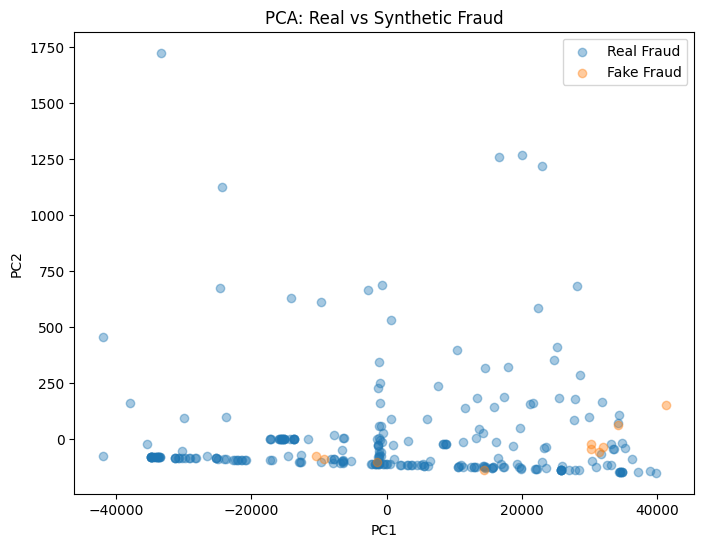

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#At first we are tring to compare it with reduced demiensions based
#On the two with the most variance
#So we tried this PCA method
# Prepare data
real = df[df['Class'] == 1].drop(columns=['Class']).values
fake = synthetic_df.drop(columns=['Class']).values

pca = PCA(n_components=2)
real_pca = pca.fit_transform(real)
fake_pca = pca.transform(fake)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(real_pca[:,0], real_pca[:,1], alpha=0.4, label='Real Fraud')
plt.scatter(fake_pca[:,0], fake_pca[:,1], alpha=0.4, label='Fake Fraud')
plt.legend()
plt.title("PCA: Real vs Synthetic Fraud")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

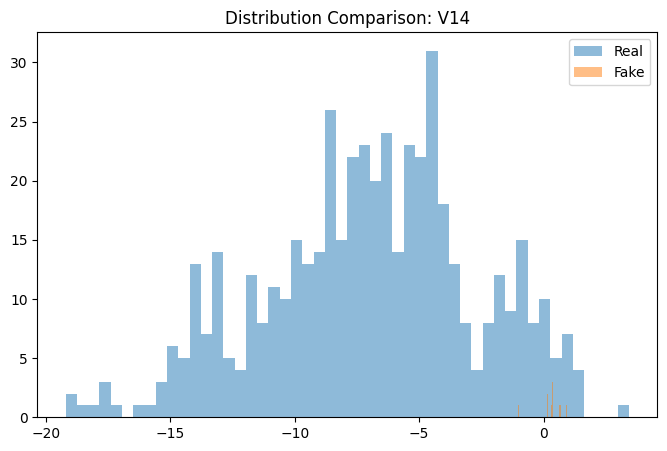

In [ ]:
import matplotlib.pyplot as plt
#Hsitogram where we can inject any column through injections

col = 'V14'

plt.figure(figsize=(8,5))
plt.hist(real_fraud[col], bins=50, alpha=0.5, label='Real')
plt.hist(synthetic_df[col], bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.title(f"Distribution Comparison: {col}")
plt.show()

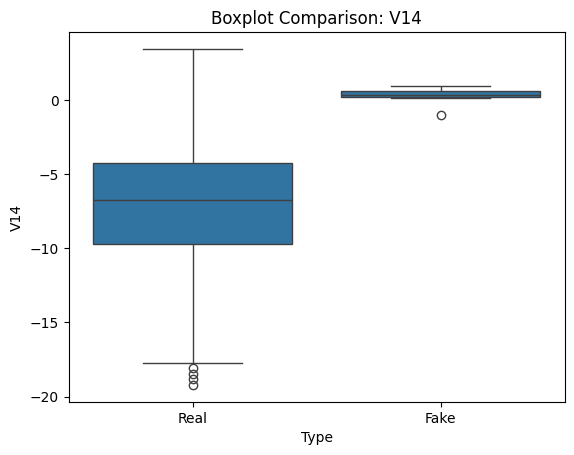

In [ ]:
#Same idea, but it hard to utilize it with a boxplot.
#Its good to show outliers, but that is it.

import seaborn as sns

col = 'V14'

combined = pd.concat([
    real_fraud[[col]].assign(Type='Real'),
    synthetic_df[[col]].assign(Type='Fake')
])

sns.boxplot(x='Type', y=col, data=combined)
plt.title(f"Boxplot Comparison: {col}")
plt.show()

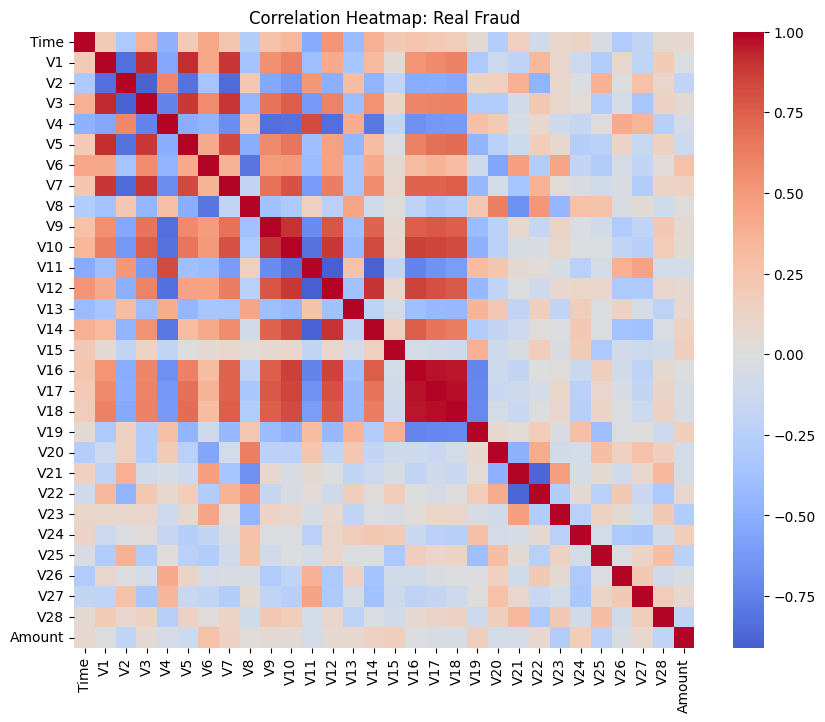

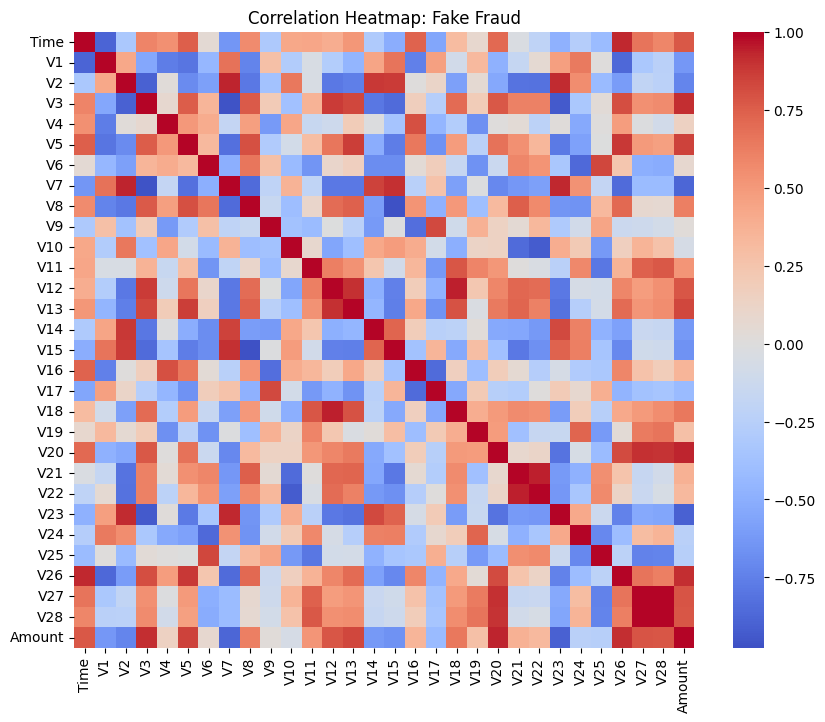

In [ ]:
#Correlation matrix is a great way to see it wholstically, so this is a potentially strong visual

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

real_df = df[df['Class'] == 1].drop(columns=['Class'])
fake_df = synthetic_df.drop(columns=['Class'])

plt.figure(figsize=(10, 8))
sns.heatmap(real_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Real Fraud')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(fake_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Fake Fraud')
plt.show()

In [ ]:
#Manually entered results into a dataframe

import pandas as pd

data = [
    ["LR Baseline", 0.0000, 0.00, 1.00],
    ["LR Balanced", 0.0299, 0.51, 0.03],
    ["Random Forest", 0.0075, 0.08, 0.23],
    ["Gradient Boosting", 0.0012, 0.005, 0.25],
    ["LR + SMOTE", 0.0302, 0.52, 0.03]
]

df = pd.DataFrame(data, columns=["Model", "F1-Score", "Recall", "Precision"])
print(df)

               Model  F1-Score  Recall  Precision
0        LR Baseline    0.0000   0.000       1.00
1        LR Balanced    0.0299   0.510       0.03
2      Random Forest    0.0075   0.080       0.23
3  Gradient Boosting    0.0012   0.005       0.25
4         LR + SMOTE    0.0302   0.520       0.03


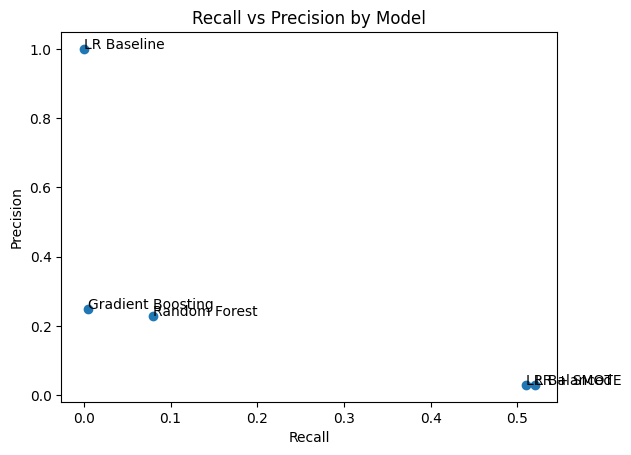

In [ ]:
#Right idea but label is distracting

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df["Recall"], df["Precision"])

for i, txt in enumerate(df["Model"]):
    plt.annotate(txt, (df["Recall"][i], df["Precision"][i]))

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Recall vs Precision by Model")

plt.show()

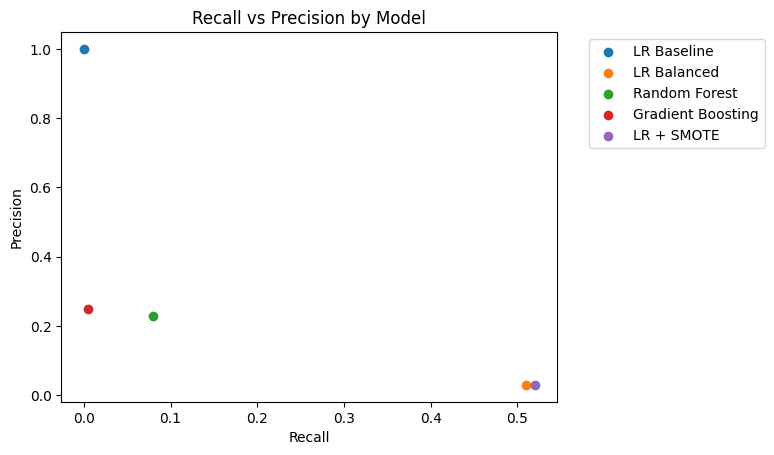

In [ ]:
#Legend adds clarity
plt.figure()


for i in range(len(df)):
    plt.scatter(df["Recall"][i], df["Precision"][i], label=df["Model"][i])


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Recall vs Precision by Model")


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()